# TV sweep: Burgers (noise=0.7, stride_x=5)

Baseline matches `noise_test.ipynb` cell 46: `noise=0.7`, `stride_x=5`.

This notebook sweeps `lambda_tv` while training `(u_model=SimpleMLP, v_model=EQL)` and records:
- final losses
- `symnet.readout.weight` and effective quadratic matrix
- a coefficient proxy for the `u*u_x` term via `M_sym[u,ux] + M_sym[ux,u]`
- derivative sanity check `||ux_fd - ux_autograd||_inf` on one time slice

TV here is implemented as a smoothed spatial TV penalty: `E[ sqrt( (?u/?x)^2 + eps^2 ) ]` (Charbonnier smoothing).


In [3]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import Datasets.load_mat_as_flat as lmf

from prog import mlps, featlib, trainer
import Datasets.matconv as mc

SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [4]:
# Dataset + training settings (noise=0.7, stride_x=5 baseline)
path = "../Datasets/data/raw/Allen_Cahn.mat"

noise = 0.7
nu = 0.02
stride_t = 1
stride_x = 5
part_num = 1
which_part = 1
seed = SEED

selected_derivs = ('u','u_x','u_xx')

lr = 1e-3
batch_size = 1000
steps = 8000
log_every = 1000

lam_pde = 0.5
lam_reg = 0.0
lam_data = 10.0

# Sweep these:
lambda_tv_values = [0.0, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0, 5.0]

# Fix activation to isolate TV effect (change if you want):
ACT = mlps.Sin


In [5]:
# Build dataset

# partitions = mc.build_dataset_from_burgers(
#     noise_level=noise,
#     nu=nu,
#     stride_t=stride_t,
#     stride_x=stride_x,
#     seed=seed,
#     quantile_splits=part_num,
#     return_partitions=True,
# )

partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


N points: 4141
x_unique: 41 t_unique: 101


In [6]:
# TV penalty (smoothed TV in space)

def tv1d_space(u_fn, t, x, eps=1e-6):
    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(ux**2 + eps**2)
    return tv.mean()


In [12]:
def make_models():
    u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64, act=ACT)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet


def make_trainer(u_model, symnet, lambda_tv: float):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lambda_pde=lam_pde,
        lambda_reg=lam_reg,
        lambda_tv=lambda_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )


def one_batch():
    idx = torch.randint(0, t_torch.shape[0], (batch_size,), device=device)
    t = t_torch[idx][:, None].float().requires_grad_(True)
    x = x_torch[idx][:, None].float().requires_grad_(True)
    u_noisy = y_noisy_torch[idx][:, None].float()
    u_clean = y_clean_torch[idx][:, None].float()
    return t, x, u_noisy, u_clean


def fd_ux(u_row, x_unique):
    dx = np.diff(x_unique)
    du = np.diff(u_row)
    ux_fd = du / dx
    x_mid = 0.5 * (x_unique[1:] + x_unique[:-1])
    return x_mid, ux_fd


def ux_autograd(model, t0, x_unique):
    x_t = torch.tensor(x_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)
    t_t = torch.full_like(x_t, float(t0))
    u_out = model(t_t, x_t)
    ux = torch.autograd.grad(
        u_out, x_t,
        grad_outputs=torch.ones_like(u_out),
        create_graph=False,
        retain_graph=False,
    )[0]
    return ux.detach().cpu().numpy().ravel()


def run_lambda_tv(lambda_tv: float):
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    u_model, symnet = make_models()
    train = make_trainer(u_model, symnet, lambda_tv=lambda_tv)

    loss_tot = []
    loss_dat = []
    loss_pde = []

    tv_trace = []

    for i in range(steps):
        t, x, u_noisy, u_clean = one_batch()
        out = train.step(t=t, x=x, u_noisy=u_noisy, u_clean=u_clean, tv_fn=tv1d_space)
        loss_tot.append(out['loss'])
        loss_dat.append(out['loss_data'])
        loss_pde.append(out['loss_pde'])

        if log_every and i % log_every == 0:
            lt = float(tv1d_space(train.u, t, x).detach().cpu().item())
            tv_trace.append((i, lt))
            print(f'[lam_tv={lambda_tv:g}] step {i}: data={out["loss_data"]:.3e} pde={out["loss_pde"]:.3e} tv={lt:.3e}')

    M_sym = symnet.effective_quadratic_matrix(symmetrize=True).detach().cpu().numpy()

    i_u, i_ux, i_uxx = 0, 1, 2
    coef_uux = float(M_sym[i_u, i_ux] + M_sym[i_ux, i_u])
    coef_uxx = float(symnet.readout.weight[0, i_uxx].detach().cpu().item())
    w_prod = float(symnet.readout.weight[0, -1].detach().cpu().item())

    # derivative check (FD on clean solver grid, autograd on trained model)
    t_unique = np.unique(t_np)
    x_unique = np.unique(x_np)
    Nt, Nx = len(t_unique), len(x_unique)

    t_to_i = {v: i for i, v in enumerate(t_unique)}
    x_to_j = {v: j for j, v in enumerate(x_unique)}
    U = np.full((Nt, Nx), np.nan, dtype=np.float64)
    for tt, xx, yy in zip(t_np, x_np, y_np):
        U[t_to_i[tt], x_to_j[xx]] = yy

    k = max(0, Nt - 2)
    t0 = t_unique[k]
    u_row = U[k, :]

    _, ux_fd = fd_ux(u_row, x_unique)
    ux_ag = ux_autograd(train.u, t0, x_unique)
    ux_err_inf = float(np.max(np.abs(ux_fd - ux_ag[1:])))


    # correct_weight = np.ndarray([0.0, 0.0, 0.02, -1.00], dtype=float)
    correct_weight = torch.tensor([[0.0, 0, 0.02, -1.00]], dtype=symnet.readout.weight.dtype, device=symnet.readout.weight.device)

    return {
        'lambda_tv': float(lambda_tv),
        'loss_final': float(loss_tot[-1]),
        'train': train,
        'loss_data_final': float(loss_dat[-1]),
        'loss_pde_final': float(loss_pde[-1]),
        'final_symnet_readout': symnet.readout.weight.detach().cpu().numpy().copy(),
        'loss_measure_tv_final': np.linalg.norm(symnet.readout.weight.detach().cpu().numpy().copy() - correct_weight.detach().cpu().numpy().copy()),
        'coef_uux_sym': coef_uux,
        'coef_uxx': coef_uxx,
        'w_prod': w_prod,
        'ux_err_inf': ux_err_inf,
        'M_sym': M_sym,
        'readout_w': symnet.readout.weight.detach().cpu().numpy().copy(),
        # 'linear_w': symnet.linear.weight.detach().cpu().numpy().copy(),
        'tv_trace': tv_trace,
    }


In [55]:
u_model, symnet = make_models()
symnet.readout.weight.detach().cpu().numpy().copy()

array([[-3.8331211e-02, -4.5716763e-05,  9.9946499e-02, -3.7767035e-01]],
      dtype=float32)

In [56]:
correct_weight = torch.tensor([[0.0, 0, 0.02, -1.00]], dtype=symnet.readout.weight.dtype, device=symnet.readout.weight.device)
np.linalg.norm(correct_weight - symnet.readout.weight.detach().cpu().numpy().copy())

C:\Users\Ethan\AppData\Local\Temp\ipykernel_13888\1801920737.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.linalg.norm(correct_weight - symnet.readout.weight.detach().cpu().numpy().copy())


np.float32(0.6286135)

In [13]:
# Run sweep over lambda_tv

results = []
for lam_tv in lambda_tv_values:
    print('=== lambda_tv =', lam_tv, '===')
    results.append(run_lambda_tv(lam_tv))

print('--- Summary ---')
for r in results:
    print(
        f"lam_tv={r['lambda_tv']:>8g} | loss={r['loss_final']:.3e} loss_data={r['loss_data_final']:.3e} loss_pde={r['loss_pde_final']:.3e} "
        # f"coef_uux_sym={r['coef_uux_sym']:+.3f} coef_uxx={r['coef_uxx']:+.4f} w_prod={r['w_prod']:+.3f} "
        # f"ux_err_inf={r['ux_err_inf']:.3e}"
        f"L2 symnet readout error={r['loss_measure_tv_final']:.3e}"
        "* * * * "
        
    )


=== lambda_tv = 0.0 ===
[lam_tv=0] step 0: data=1.030e+00 pde=2.822e-03 tv=2.847e-02
[lam_tv=0] step 1000: data=6.619e-01 pde=3.743e-02 tv=1.684e+00
[lam_tv=0] step 2000: data=5.456e-01 pde=1.274e-01 tv=2.148e+00
[lam_tv=0] step 3000: data=5.200e-01 pde=1.487e-01 tv=2.427e+00
[lam_tv=0] step 4000: data=5.009e-01 pde=1.292e-01 tv=2.232e+00
[lam_tv=0] step 5000: data=5.091e-01 pde=1.102e-01 tv=2.287e+00
[lam_tv=0] step 6000: data=4.709e-01 pde=9.850e-02 tv=2.315e+00
[lam_tv=0] step 7000: data=4.698e-01 pde=8.855e-02 tv=2.360e+00
=== lambda_tv = 1e-06 ===
[lam_tv=1e-06] step 0: data=1.030e+00 pde=2.822e-03 tv=2.847e-02
[lam_tv=1e-06] step 1000: data=6.619e-01 pde=3.743e-02 tv=1.684e+00
[lam_tv=1e-06] step 2000: data=5.456e-01 pde=1.274e-01 tv=2.148e+00
[lam_tv=1e-06] step 3000: data=5.200e-01 pde=1.487e-01 tv=2.427e+00
[lam_tv=1e-06] step 4000: data=5.009e-01 pde=1.292e-01 tv=2.232e+00
[lam_tv=1e-06] step 5000: data=5.091e-01 pde=1.102e-01 tv=2.287e+00
[lam_tv=1e-06] step 6000: data=4.709

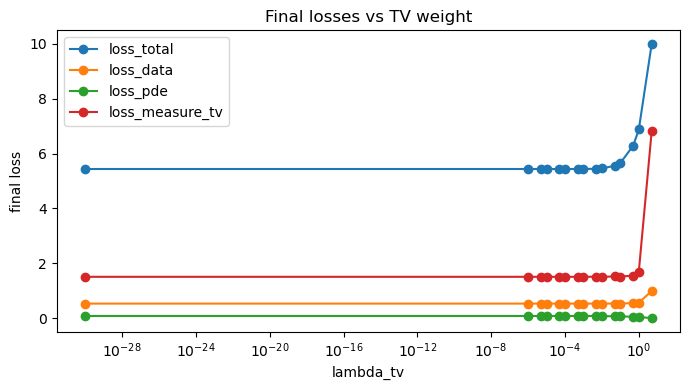

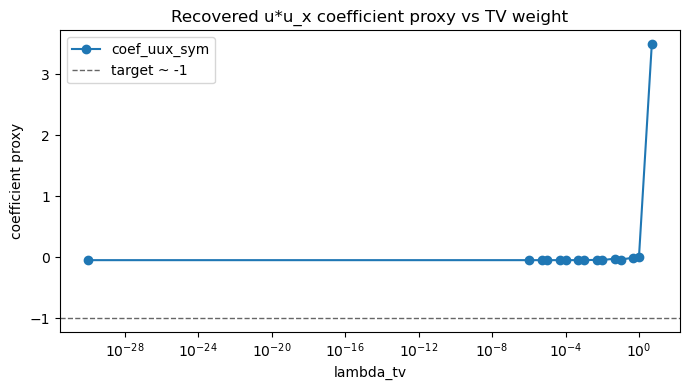

In [15]:
# Plot metrics vs lambda_tv

lam = np.array([r['lambda_tv'] for r in results], dtype=float)
ltv = np.array([r['loss_measure_tv_final'] for r in results], dtype=float)
ltot = np.array([r['loss_final'] for r in results], dtype=float)
ld  = np.array([r['loss_data_final'] for r in results], dtype=float)
lp  = np.array([r['loss_pde_final'] for r in results], dtype=float)
cuux = np.array([r['coef_uux_sym'] for r in results], dtype=float)

plt.figure(figsize=(7,4))
plt.semilogx(lam + 1e-30, ltot, marker='o', label='loss_total')
plt.semilogx(lam + 1e-30, ld, marker='o', label='loss_data')
plt.semilogx(lam + 1e-30, lp, marker='o', label='loss_pde')
plt.semilogx(lam + 1e-30, ltv, marker='o', label='loss_measure_tv')
plt.xlabel('lambda_tv')
plt.ylabel('final loss')
plt.title('Final losses vs TV weight')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.semilogx(lam + 1e-30, cuux, marker='o', label='coef_uux_sym')
plt.axhline(-1.0, color='k', linestyle='--', linewidth=1, alpha=0.6, label='target ~ -1')
plt.xlabel('lambda_tv')
plt.ylabel('coefficient proxy')
plt.title('Recovered u*u_x coefficient proxy vs TV weight')
plt.legend()
plt.tight_layout()
plt.show()


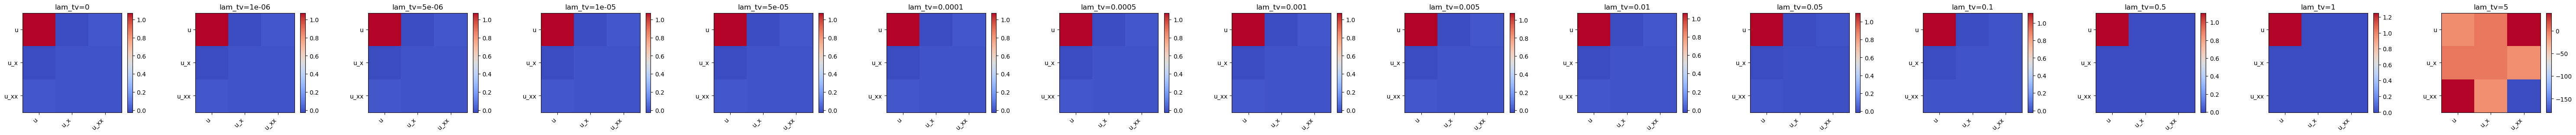

In [16]:
# Visualize learned M_sym per lambda_tv

fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 3), constrained_layout=True)
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    im = ax.imshow(r['M_sym'], cmap='coolwarm')
    ax.set_title(f"lam_tv={r['lambda_tv']:g}")
    ax.set_xticks(range(len(selected_derivs)))
    ax.set_yticks(range(len(selected_derivs)))
    ax.set_xticklabels(selected_derivs, rotation=45, ha='right')
    ax.set_yticklabels(selected_derivs)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()
